In [64]:
import sys
sys.path.append('..')
from src.evaluation import load_all_results
import numpy as np
import pandas as pd
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
from IPython.display import display
from scipy.stats import chi2_contingency
from pathlib import Path
from src.inference import load_predictions
from src.data_loading import get_image_dimensions, detect_visible_side
from src import (
    parse_cvat_annotations,
    split_frames_into_videos,
)

In [65]:
results = load_all_results('./results/')

YOLO_MODELS = [
    'YOLO11-Nano',
    'YOLO11-Small',
    'YOLO11-Medium',
    'YOLO11-Large',
    'YOLO11-XL',
]

MEDIAPIPE_MODELS = [
    'MediaPipe-Lite',
    'MediaPipe-Full',
    'MediaPipe-Heavy',
]

VITPOSE_BASE = [
    'ViTPose-Base-Simple',
    'ViTPose-Base',
]

VITPOSE_PLUS_COCO = [
    'ViTPose-Plus-Small (COCO)',
    'ViTPose-Plus-Base (COCO)',
    'ViTPose-Plus-Large (COCO)',
    'ViTPose-Plus-Huge (COCO)',
]

VITPOSE_PLUS_MPII = [
    'ViTPose-Plus-Small (MPII)',
    'ViTPose-Plus-Base (MPII)',
    'ViTPose-Plus-Large (MPII)',
    'ViTPose-Plus-Huge (MPII)',
]

HRNET = [
    'HRNet-W32-256x192',
    'HRNet-W32-384x288',
    'HRNet-W48-384x288',
]

OPENPOSE = [
    'OpenPose-Lite',
    'OpenPose-MPI',
    'OpenPose-BODY_25',
    'OpenPose-COCO',
]

ALL_MODELS = YOLO_MODELS + MEDIAPIPE_MODELS + VITPOSE_BASE + VITPOSE_PLUS_COCO + VITPOSE_PLUS_MPII + HRNET + OPENPOSE

group_names = ['YOLO11', 'MediaPipe', 'OpenPose', 'ViTPose', 'ViTPose+ MPII', 'ViTPose+ COCO', 'HRNet']
ALL_MODELS_GROUPED = [YOLO_MODELS, MEDIAPIPE_MODELS, OPENPOSE, VITPOSE_BASE, VITPOSE_PLUS_MPII, VITPOSE_PLUS_COCO, HRNET]

In [66]:
def clean_model_name(name):
    # special handling for vitpose base variants
    if name == "ViTPose-Base":
        return "Base"

    if name == "ViTPose-Base-Simple":
        return "Simple"

    prefixes = [
        "YOLO11-",
        "MediaPipe-",
        "ViTPose-Plus-",
        "OpenPose-",
        "HRNet-",
    ]

    for p in prefixes:
        name = name.replace(p, "")

    # remove dataset labels
    name = re.sub(r"\s*\(.*?\)", "", name)

    # clean HRNet formatting
    name = re.sub(r"(W\d+)-", r"\1 ", name)

    return name.strip()

In [67]:
KEYPOINTS_NO_FOOT = ['shoulder', 'elbow', 'wrist', 'hip', 'knee', 'ankle']
JOINTS_NO_ANKLE = ['knee', 'hip', 'elbow']

def table_adjusted_metrics(results, all_models_grouped, group_names):
    rows = []
    index_labels = []

    for group, family_name in zip(all_models_grouped, group_names):
        aucs = []
        mes = []
        maes = []
        rmses = []

        for model_name in group:
            per_kp = results[model_name]['aggregated']['auc']['per_keypoint']
            auc = np.mean([per_kp[kp]['mean'] for kp in KEYPOINTS_NO_FOOT if kp in per_kp])

            per_joint_me   = results[model_name]['aggregated']['angle_me']['per_joint']
            per_joint_mae  = results[model_name]['aggregated']['angle_mae']['per_joint']
            per_joint_rmse = results[model_name]['aggregated']['angle_rmse']['per_joint']

            me   = np.mean([per_joint_me[j]['mean']   for j in JOINTS_NO_ANKLE if j in per_joint_me])
            mae  = np.mean([per_joint_mae[j]['mean']  for j in JOINTS_NO_ANKLE if j in per_joint_mae])
            rmse = np.mean([per_joint_rmse[j]['mean'] for j in JOINTS_NO_ANKLE if j in per_joint_rmse])

            aucs.append(auc)
            mes.append(me)
            maes.append(mae)
            rmses.append(rmse)

        best_auc  = max(aucs)
        best_me   = min(mes, key=abs)  # closest to zero is best for signed error
        best_mae  = min(maes)
        best_rmse = min(rmses)

        for model_name, auc, me, mae, rmse in zip(group, aucs, mes, maes, rmses):
            label = f"{family_name} / {clean_model_name(model_name)}"
            auc_str  = f'\\textbf{{{auc:.1f}}}'   if auc  == best_auc  else f'{auc:.1f}'
            me_str   = f'\\textbf{{{me:+.2f}}}'   if me   == best_me   else f'{me:+.2f}'
            mae_str  = f'\\textbf{{{mae:.2f}}}'   if mae  == best_mae  else f'{mae:.2f}'
            rmse_str = f'\\textbf{{{rmse:.2f}}}'  if rmse == best_rmse else f'{rmse:.2f}'
            rows.append({
                'ME (no ankle)':   me_str,
                'MAE (no ankle)':  mae_str,
                'RMSE (no ankle)': rmse_str,
                'AUC (no foot)':   auc_str,
            })
            index_labels.append(label)

    df_str = pd.DataFrame(rows, index=index_labels)
    print(df_str.to_latex(escape=False))

    # numeric version for display
    rows_num = []
    for group, family_name in zip(all_models_grouped, group_names):
        for model_name in group:
            per_kp = results[model_name]['aggregated']['auc']['per_keypoint']
            auc = np.mean([per_kp[kp]['mean'] for kp in KEYPOINTS_NO_FOOT if kp in per_kp])

            per_joint_me   = results[model_name]['aggregated']['angle_me']['per_joint']
            per_joint_mae  = results[model_name]['aggregated']['angle_mae']['per_joint']
            per_joint_rmse = results[model_name]['aggregated']['angle_rmse']['per_joint']

            me   = np.mean([per_joint_me[j]['mean']   for j in JOINTS_NO_ANKLE if j in per_joint_me])
            mae  = np.mean([per_joint_mae[j]['mean']  for j in JOINTS_NO_ANKLE if j in per_joint_mae])
            rmse = np.mean([per_joint_rmse[j]['mean'] for j in JOINTS_NO_ANKLE if j in per_joint_rmse])

            rows_num.append({
                'ME (no ankle)':   me,
                'MAE (no ankle)':  mae,
                'RMSE (no ankle)': rmse,
                'AUC (no foot)':   auc,
            })

    df_num = pd.DataFrame(rows_num, index=index_labels)
    display(df_num.round(2))
    return df_num

df_adj = table_adjusted_metrics(results, ALL_MODELS_GROUPED, group_names)

\begin{tabular}{lllll}
\toprule
 & ME (no ankle) & MAE (no ankle) & RMSE (no ankle) & AUC (no foot) \\
\midrule
YOLO11 / Nano & \textbf{+6.04} & 12.19 & 13.82 & 61.0 \\
YOLO11 / Small & +8.04 & 12.75 & 14.35 & 65.0 \\
YOLO11 / Medium & +6.91 & 10.87 & 12.29 & 70.1 \\
YOLO11 / Large & +8.24 & 11.80 & 13.22 & 69.2 \\
YOLO11 / XL & +7.79 & \textbf{10.65} & \textbf{11.52} & \textbf{71.9} \\
MediaPipe / Lite & +4.28 & 10.59 & 13.11 & 63.6 \\
MediaPipe / Full & +4.15 & 9.05 & 11.46 & 69.6 \\
MediaPipe / Heavy & \textbf{+3.95} & \textbf{8.73} & \textbf{11.25} & \textbf{73.5} \\
OpenPose / Lite & +6.71 & 9.66 & 10.75 & 68.5 \\
OpenPose / MPI & \textbf{+4.32} & \textbf{5.43} & \textbf{5.77} & 74.8 \\
OpenPose / BODY_25 & +6.20 & 6.97 & 7.52 & \textbf{80.0} \\
OpenPose / COCO & +5.92 & 7.16 & 7.67 & 77.6 \\
ViTPose / Simple & +5.98 & 7.01 & 7.36 & 80.2 \\
ViTPose / Base & \textbf{+5.70} & \textbf{6.72} & \textbf{7.06} & \textbf{80.9} \\
ViTPose+ MPII / Small & \textbf{+3.50} & 7.10 & 9.24 & 79.6

,ME (no ankle),MAE (no ankle),RMSE (no ankle),AUC (no foot)
YOLO11 / Nano,6.04,12.19,13.82,61.04
YOLO11 / Small,8.04,12.75,14.35,65.01
YOLO11 / Medium,6.91,10.87,12.29,70.10
YOLO11 / Large,8.24,11.80,13.22,69.23
YOLO11 / XL,7.79,10.65,11.52,71.93
MediaPipe / Lite,4.28,10.59,13.11,63.57
MediaPipe / Full,4.15,9.05,11.46,69.59
MediaPipe / Heavy,3.95,8.73,11.25,73.51
OpenPose / Lite,6.71,9.66,10.75,68.48
OpenPose / MPI,4.32,5.43,5.77,74.84


In [68]:
VITPOSE_FAMILIES = {'ViTPose', 'ViTPose+ COCO', 'ViTPose+ MPII'}
VITPOSE_MERGED_NAME = 'ViTPose'

def get_best_models(results, all_models_grouped, group_names):
    best = {}
    vitpose_candidates = {}

    def rmse_no_ankle(m):
        per_joint = results[m]['aggregated']['angle_rmse']['per_joint']
        vals = [per_joint[j]['mean'] for j in JOINTS_NO_ANKLE if j in per_joint]
        return np.mean(vals)

    for group, name in zip(all_models_grouped, group_names):
        best_model = min(group, key=rmse_no_ankle)

        if name in VITPOSE_FAMILIES:
            vitpose_candidates[best_model] = rmse_no_ankle(best_model)
        else:
            best[name] = best_model
            print(f"{name}: {best_model} ({rmse_no_ankle(best_model):.2f}°)")

    best_vitpose = min(vitpose_candidates, key=vitpose_candidates.get)
    best[VITPOSE_MERGED_NAME] = best_vitpose
    print(f"{VITPOSE_MERGED_NAME}: {best_vitpose} ({vitpose_candidates[best_vitpose]:.2f}°)")

    return best

best_models = get_best_models(results, ALL_MODELS_GROUPED, group_names)

YOLO11: YOLO11-XL (11.52°)
MediaPipe: MediaPipe-Heavy (11.25°)
OpenPose: OpenPose-MPI (5.77°)
HRNet: HRNet-W32-384x288 (7.82°)
ViTPose: ViTPose-Plus-Large (MPII) (5.39°)


In [69]:
def get_all_models(all_models_grouped, group_names):
    all_models = {}
    for group, name in zip(all_models_grouped, group_names):
        for model_name in group:
            label = f"{name} / {clean_model_name(model_name)}"
            all_models[label] = model_name
    return all_models

all_models_flat = get_all_models(ALL_MODELS_GROUPED, group_names)

In [70]:
KEYPOINTS = ['shoulder', 'elbow', 'wrist', 'hip', 'knee', 'ankle', 'foot_index']

def table_per_keypoint_auc(results, best_models):
    # columns are model group names, rows are keypoints
    col_labels = {name: name for name, model in best_models.items()}    
    data = {}
    for family_name, model_name in best_models.items():
        auc_per_kp = results[model_name]['aggregated']['auc']['per_keypoint']
        col = {}
        for kp in KEYPOINTS:
            col[kp] = auc_per_kp[kp]['mean'] if kp in auc_per_kp else None
        data[col_labels[family_name]] = col

    df = pd.DataFrame(data, index=KEYPOINTS)

    # mean row
    df.loc['mean'] = df.drop(index='foot_index').mean()

    # bold best per row
    def bold_max(row):
        max_val = row.max()
        return [f'\\textbf{{{v:.1f}}}' if v == max_val else f'{v:.1f}' for v in row]

    df_str = df.apply(bold_max, axis=1, result_type='expand')
    df_str.columns = df.columns
    df_str.index = df.index

    print(df_str.to_latex(escape=False))
    return df

df = table_per_keypoint_auc(results, best_models)
display(df.round(1))

\begin{tabular}{llllll}
\toprule
 & YOLO11 & MediaPipe & OpenPose & HRNet & ViTPose \\
\midrule
shoulder & 76.2 & 71.5 & 83.2 & 82.4 & \textbf{85.4} \\
elbow & 79.5 & 77.7 & 81.5 & 81.8 & \textbf{82.1} \\
wrist & 85.0 & 84.7 & 87.7 & 89.2 & \textbf{89.3} \\
hip & 55.0 & 66.3 & 64.2 & 67.3 & \textbf{70.5} \\
knee & 70.1 & 75.3 & 75.6 & 83.1 & \textbf{85.3} \\
ankle & 65.8 & 65.6 & 56.7 & \textbf{79.8} & 73.4 \\
foot_index & nan & \textbf{65.6} & nan & nan & nan \\
mean & 71.9 & 73.5 & 74.8 & 80.6 & \textbf{81.0} \\
\bottomrule
\end{tabular}



,YOLO11,MediaPipe,OpenPose,HRNet,ViTPose
shoulder,76.2,71.5,83.2,82.4,85.4
elbow,79.5,77.7,81.5,81.8,82.1
wrist,85.0,84.7,87.7,89.2,89.3
hip,55.0,66.3,64.2,67.3,70.5
knee,70.1,75.3,75.6,83.1,85.3
ankle,65.8,65.6,56.7,79.8,73.4
foot_index,NaN,65.6,NaN,NaN,NaN
mean,71.9,73.5,74.8,80.6,81.0


In [71]:
JOINT_ANGLES = {
    'knee':  ('hip',   'knee',  'ankle'),
    'hip':   ('shoulder', 'hip', 'knee'),
    'ankle': ('knee',  'ankle', 'foot_index'),
    'elbow': ('shoulder', 'elbow', 'wrist'),
}
JOINT_ORDER = ['knee', 'hip', 'ankle', 'elbow']



def table_per_joint_angle_metric(results, best_models, metric='angle_mae'):
    assert metric in ('angle_mae', 'angle_rmse', 'angle_me'), f"Unknown metric: {metric}"
    lower_is_better = metric in ('angle_mae', 'angle_rmse')

    data = {}
    for family_name, model_name in best_models.items():
        per_joint = results[model_name]['aggregated'][metric]['per_joint']
        data[family_name] = {
            joint: per_joint[joint]['mean'] if joint in per_joint else None
            for joint in JOINT_ORDER
        }

    df = pd.DataFrame(data, index=JOINT_ORDER)
    df.loc['mean'] = df.loc[JOINTS_NO_ANKLE].mean()

    def bold_best(row):
        valid = row.dropna()
        best_val = valid.min() if lower_is_better else valid.max()
        result = []
        for v in row:
            if v is None or pd.isna(v):
                result.append('—')
            elif v == best_val:
                result.append(f'\\textbf{{{v:.2f}}}')
            else:
                result.append(f'{v:.2f}')
        return result

    df_str = df.apply(bold_best, axis=1, result_type='expand')
    df_str.columns = df.columns
    df_str.index = df.index

    print(df_str.to_latex(escape=False))
    return df



In [72]:
df_mae  = table_per_joint_angle_metric(results, best_models, metric='angle_mae')
display(df_mae.round(2))

\begin{tabular}{llllll}
\toprule
 & YOLO11 & MediaPipe & OpenPose & HRNet & ViTPose \\
\midrule
knee & 15.55 & 10.22 & 7.28 & 9.41 & \textbf{7.04} \\
hip & 9.45 & 7.78 & 4.20 & 7.34 & \textbf{3.87} \\
ankle & — & \textbf{18.00} & — & — & — \\
elbow & 6.97 & 8.19 & 4.80 & 5.68 & \textbf{4.42} \\
mean & 10.65 & 8.73 & 5.43 & 7.48 & \textbf{5.11} \\
\bottomrule
\end{tabular}



,YOLO11,MediaPipe,OpenPose,HRNet,ViTPose
knee,15.55,10.22,7.28,9.41,7.04
hip,9.45,7.78,4.20,7.34,3.87
ankle,NaN,18.00,NaN,NaN,NaN
elbow,6.97,8.19,4.80,5.68,4.42
mean,10.65,8.73,5.43,7.48,5.11


In [73]:
df_rmse = table_per_joint_angle_metric(results, best_models, metric='angle_rmse')
display(df_rmse.round(2))

\begin{tabular}{llllll}
\toprule
 & YOLO11 & MediaPipe & OpenPose & HRNet & ViTPose \\
\midrule
knee & 16.53 & 12.30 & 7.63 & 9.65 & \textbf{7.33} \\
hip & 10.20 & 10.06 & 4.59 & 7.61 & \textbf{4.17} \\
ankle & — & \textbf{20.86} & — & — & — \\
elbow & 7.82 & 11.38 & 5.10 & 6.20 & \textbf{4.66} \\
mean & 11.52 & 11.25 & 5.77 & 7.82 & \textbf{5.39} \\
\bottomrule
\end{tabular}



,YOLO11,MediaPipe,OpenPose,HRNet,ViTPose
knee,16.53,12.30,7.63,9.65,7.33
hip,10.20,10.06,4.59,7.61,4.17
ankle,NaN,20.86,NaN,NaN,NaN
elbow,7.82,11.38,5.10,6.20,4.66
mean,11.52,11.25,5.77,7.82,5.39


In [74]:
df_me   = table_per_joint_angle_metric(results, best_models, metric='angle_me')
display(df_me.round(2))

\begin{tabular}{llllll}
\toprule
 & YOLO11 & MediaPipe & OpenPose & HRNet & ViTPose \\
\midrule
knee & \textbf{15.51} & 6.68 & 6.83 & 9.36 & 6.76 \\
hip & \textbf{9.08} & 3.99 & 2.93 & 6.95 & 2.95 \\
ankle & — & \textbf{17.70} & — & — & — \\
elbow & -1.23 & 1.18 & \textbf{3.21} & 2.65 & 2.01 \\
mean & \textbf{7.79} & 3.95 & 4.32 & 6.32 & 3.91 \\
\bottomrule
\end{tabular}



,YOLO11,MediaPipe,OpenPose,HRNet,ViTPose
knee,15.51,6.68,6.83,9.36,6.76
hip,9.08,3.99,2.93,6.95,2.95
ankle,NaN,17.70,NaN,NaN,NaN
elbow,-1.23,1.18,3.21,2.65,2.01
mean,7.79,3.95,4.32,6.32,3.91


In [75]:
def table_per_keypoint_dr(results, best_models):
    data = {}
    for family_name, model_name in best_models.items():
        dr_per_kp = results[model_name]['aggregated']['detection_rate']['per_keypoint']
        col = {}
        for kp in KEYPOINTS:
            col[kp] = dr_per_kp[kp]['mean'] * 100 if kp in dr_per_kp else None
        data[family_name] = col

    df = pd.DataFrame(data, index=KEYPOINTS)
    df.loc['mean'] = df.drop(index='foot_index').mean()

    def fmt_row(row):
        valid = row.dropna()
        max_val = valid.max() if not valid.empty else None
        out = []
        for v in row:
            if v is None or np.isnan(v):
                out.append('—')
            elif v == max_val:
                out.append(f'\\textbf{{{v:.1f}}}')
            else:
                out.append(f'{v:.1f}')
        return out

    df_str = df.apply(fmt_row, axis=1, result_type='expand')
    df_str.columns = df.columns
    df_str.index = df.index

    print(df_str.to_latex(escape=False))
    return df

df_dr = table_per_keypoint_dr(results, best_models)
display(df_dr.round(1))

\begin{tabular}{llllll}
\toprule
 & YOLO11 & MediaPipe & OpenPose & HRNet & ViTPose \\
\midrule
shoulder & \textbf{100.0} & 99.4 & 87.3 & \textbf{100.0} & \textbf{100.0} \\
elbow & \textbf{100.0} & 99.4 & 85.8 & \textbf{100.0} & \textbf{100.0} \\
wrist & \textbf{100.0} & 99.4 & 85.8 & \textbf{100.0} & \textbf{100.0} \\
hip & \textbf{100.0} & 99.4 & 79.4 & \textbf{100.0} & \textbf{100.0} \\
knee & \textbf{100.0} & 99.4 & 79.2 & \textbf{100.0} & \textbf{100.0} \\
ankle & \textbf{100.0} & 99.4 & 74.0 & \textbf{100.0} & \textbf{100.0} \\
foot_index & — & \textbf{99.4} & — & — & — \\
mean & \textbf{100.0} & 99.4 & 81.9 & \textbf{100.0} & \textbf{100.0} \\
\bottomrule
\end{tabular}



,YOLO11,MediaPipe,OpenPose,HRNet,ViTPose
shoulder,100.0,99.4,87.3,100.0,100.0
elbow,100.0,99.4,85.8,100.0,100.0
wrist,100.0,99.4,85.8,100.0,100.0
hip,100.0,99.4,79.4,100.0,100.0
knee,100.0,99.4,79.2,100.0,100.0
ankle,100.0,99.4,74.0,100.0,100.0
foot_index,NaN,99.4,NaN,NaN,NaN
mean,100.0,99.4,81.9,100.0,100.0


In [76]:
TWO_STAGE = {'ViTPose', 'HRNet'}

def print_fps_best_models(results, best_models):
    sorted_models = sorted(
        best_models.items(),
        key=lambda x: results[x[1]]['inference_time']['fps']
    )

    for family_name, model_name in sorted_models:
        fps = results[model_name]['inference_time']['fps']
        is_two_stage = family_name in TWO_STAGE
        print(f"  {family_name} ({model_name}): FPS={fps:.1f}, two-stage={is_two_stage}")

print_fps_best_models(results, best_models)

  OpenPose (OpenPose-MPI): FPS=0.1, two-stage=False
  ViTPose (ViTPose-Plus-Large (MPII)): FPS=0.7, two-stage=True
  HRNet (HRNet-W32-384x288): FPS=1.1, two-stage=True
  YOLO11 (YOLO11-XL): FPS=1.7, two-stage=False
  MediaPipe (MediaPipe-Heavy): FPS=13.1, two-stage=False


In [77]:
gt_keypoints, head_bboxes = parse_cvat_annotations('./data/annotations/annotations.xml')
videos = split_frames_into_videos(gt_keypoints, head_bboxes)

def _load_predictions(predictions_dir, model_names):
    """
    Returns dict {model_name -> (predictions, keypoint_mapping)}
    """
    all_preds = {}
    for model_name in model_names:
        path = Path(predictions_dir) / f"{model_name}.json"
        if not path.exists():
            print(f"Warning: {path} not found, skipping")
            continue
        _, kp_mapping, predictions, _ = load_predictions(path)
        all_preds[model_name] = (predictions, kp_mapping)
    return all_preds

def _joint_angles(video_data, predictions, keypoint_mapping, img_w, img_h, side, joint):
    def _angle(a, b, c):
        ba = np.array(a) - np.array(b)
        bc = np.array(c) - np.array(b)
        n_ba, n_bc = np.linalg.norm(ba), np.linalg.norm(bc)
        if n_ba == 0 or n_bc == 0:
            return np.nan
        return 180.0 - np.degrees(np.arccos(np.clip(np.dot(ba, bc) / (n_ba * n_bc), -1.0, 1.0)))

    kp_a, kp_b, kp_c = [f'{side}_{k}' for k in JOINT_ANGLES[joint]]
    idx_a = keypoint_mapping.get(kp_a)
    idx_b = keypoint_mapping.get(kp_b)
    idx_c = keypoint_mapping.get(kp_c)

    frames = sorted(video_data['frames'])
    gt_kps = video_data['keypoints']
    n = len(frames)
    gt_out, pred_out = np.full(n, np.nan), np.full(n, np.nan)

    for i, f in enumerate(frames):
        kps = gt_kps.get(f, {})
        if all(k in kps and not kps[k]['occluded'] for k in [kp_a, kp_b, kp_c]):
            gt_out[i] = _angle(
                (kps[kp_a]['x'], kps[kp_a]['y']),
                (kps[kp_b]['x'], kps[kp_b]['y']),
                (kps[kp_c]['x'], kps[kp_c]['y']),
            )

        if None in (idx_a, idx_b, idx_c) or predictions is None:
            continue
        pred = predictions.get(f)
        if pred is None:
            continue
        pa, pb, pc = pred[idx_a], pred[idx_b], pred[idx_c]
        if any(p.confidence == 0.0 for p in [pa, pb, pc]):
            continue
        pred_out[i] = _angle(
            (pa.x * img_w, pa.y * img_h),
            (pb.x * img_w, pb.y * img_h),
            (pc.x * img_w, pc.y * img_h),
        )

    return gt_out, pred_out


C:\Users\matth\AppData\Local\Temp\ipykernel_56092\1816014768.py:70: RuntimeWarning: Mean of empty slice
  ax1.plot(pedal_axis, np.nanmean(stack, axis=0),
C:\Users\matth\AppData\Local\Temp\ipykernel_56092\1816014768.py:88: RuntimeWarning: Mean of empty slice
  ax_err.plot(pedal_axis, np.nanmean(error_stack, axis=0),
c:\Users\matth\Desktop\Bike-Fit\notebooks\02_pose_estimation\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


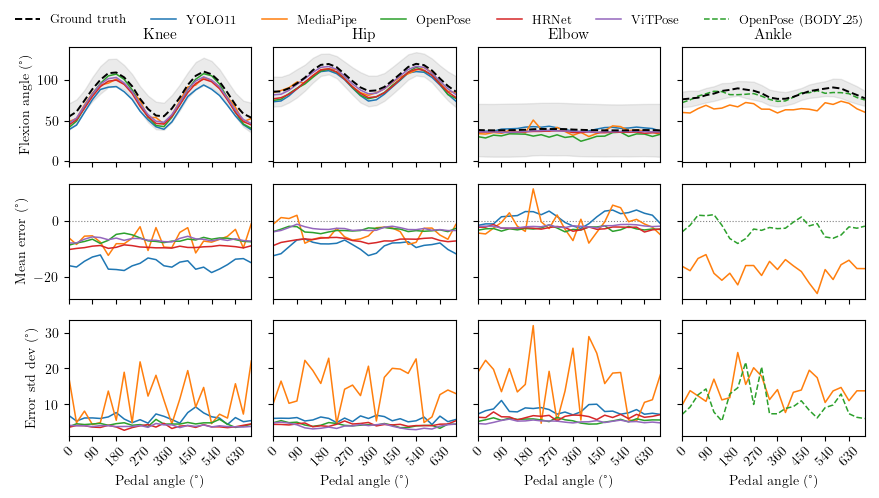

In [78]:
# After best_models is defined, create ankle override
ankle_models = {**best_models, 'OpenPose': 'OpenPose-BODY_25'}

def plot_angle_waveform_all(videos, best_models, predictions_dir,
                             frames_per_video=24, total_pedal_degrees=690,
                             figsize=(8.8, 4.9), ankle_models=None):
    joints = ['knee', 'hip', 'elbow', 'ankle']
    pedal_axis = np.linspace(0, total_pedal_degrees, frames_per_video)
    
    joint_models = {j: best_models for j in joints}
    if ankle_models is not None:
        joint_models['ankle'] = ankle_models

    all_model_names = list(set(
        m for models in joint_models.values() for m in models.values()
    ))
    all_preds = _load_predictions(predictions_dir, all_model_names)

    gt_by_video   = {joint: {} for joint in joints}
    pred_by_model = {joint: {m: {} for m in joint_models[joint].values()} for joint in joints}

    for vid_id, vdata in videos.items():
        sample_frame = next(iter(vdata['keypoints']))
        img_w, img_h = get_image_dimensions(sample_frame)
        side = detect_visible_side(vdata['keypoints'])

        first_preds, first_map = next(iter(all_preds.values()))

        for joint in joints:
            gt_angles, _ = _joint_angles(vdata, first_preds, first_map, img_w, img_h, side, joint)
            gt_by_video[joint][vid_id] = gt_angles

            for family, mname in joint_models[joint].items():
                if mname not in all_preds:
                    continue
                preds, mapping = all_preds[mname]
                _, pred_angles = _joint_angles(vdata, preds, mapping, img_w, img_h, side, joint)
                pred_by_model[joint][mname][vid_id] = pred_angles

    all_families = list(best_models.keys())
    colors = {fname: plt.cm.tab10(i) for i, fname in enumerate(all_families)}

    fig, axes = plt.subplots(3, len(joints), figsize=figsize,
                             sharex=True, sharey='row')

    for col, joint in enumerate(joints):
        ax1    = axes[0, col]
        ax_err = axes[1, col]
        ax2    = axes[2, col]

        gt_stack = np.array([gt_by_video[joint][v] for v in videos])
        gt_mean  = np.nanmean(gt_stack, axis=0)
        gt_std   = np.nanstd(gt_stack,  axis=0)

        ax1.plot(pedal_axis, gt_mean, color='black', linestyle='--',
                 linewidth=1.4, label='Ground truth', zorder=5)
        ax1.fill_between(pedal_axis, gt_mean - gt_std, gt_mean + gt_std,
                         color='black', alpha=0.08)

        for family, mname in joint_models[joint].items():
            if mname not in all_preds:
                continue
            stack = np.array([pred_by_model[joint][mname].get(v, np.full(frames_per_video, np.nan))
                               for v in videos])

            is_body25 = (joint == 'ankle' and mname == 'OpenPose-BODY_25')
            linestyle = '--' if is_body25 else '-'
            label = f'{family} (BODY\\_25)' if is_body25 else family

            ax1.plot(pedal_axis, np.nanmean(stack, axis=0),
                     color=colors[family], linewidth=1.1,
                     label=label, linestyle=linestyle)

        ax1.set_title(f'{joint.capitalize()}', fontsize=11)

        ax_err.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        for family, mname in joint_models[joint].items():
            if mname not in all_preds:
                continue
            stack = np.array([pred_by_model[joint][mname].get(v, np.full(frames_per_video, np.nan))
                               for v in videos])
            gt_stack_aligned = np.array([gt_by_video[joint][v] for v in videos])
            error_stack = stack - gt_stack_aligned

            is_body25 = (joint == 'ankle' and mname == 'OpenPose-BODY_25')
            linestyle = '--' if is_body25 else '-'

            ax_err.plot(pedal_axis, np.nanmean(error_stack, axis=0),
                        color=colors[family], linewidth=1.1, linestyle=linestyle)

        for family, mname in joint_models[joint].items():
            if mname not in all_preds:
                continue
            stack = np.array([pred_by_model[joint][mname].get(v, np.full(frames_per_video, np.nan))
                               for v in videos])
            gt_stack_aligned = np.array([gt_by_video[joint][v] for v in videos])
            error_stack = stack - gt_stack_aligned

            is_body25 = (joint == 'ankle' and mname == 'OpenPose-BODY_25')
            linestyle = '--' if is_body25 else '-'

            ax2.plot(pedal_axis, np.nanstd(error_stack, axis=0),
                     color=colors[family], linewidth=1.1, linestyle=linestyle)

        ax2.set_xlabel('Pedal angle (°)', fontsize=10)
        ax2.set_xlim(0, total_pedal_degrees)
        ax2.set_xticks(np.arange(0, total_pedal_degrees + 1, 90))
        ax2.tick_params(axis='x', labelrotation=45)

    axes[0, 0].set_ylabel('Flexion angle (°)', fontsize=10)
    axes[1, 0].set_ylabel('Mean error (°)', fontsize=10)
    axes[2, 0].set_ylabel('Error std dev (°)', fontsize=10)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    
    all_handles, all_labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in all_labels:
                all_handles.append(handle)
                all_labels.append(label)

    fig.legend(all_handles, all_labels, loc='upper center', ncol=len(best_models) + 2,
            fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.02))

    plt.tight_layout()
    plt.savefig('plots/all_waveforms.pdf', bbox_inches='tight')
    plt.show()


plot_angle_waveform_all(videos, best_models, './predictions/', ankle_models=ankle_models)

Metadata analysis - RMSE (no ankle)

  bike_type:
    mountain bike    RMSE=7.23±1.63°  (n=6)
    road bike        RMSE=7.57±1.59°  (n=10)
    time trial       RMSE=11.86±2.22°  (n=4)

  gender:
    female           RMSE=6.54±1.36°  (n=4)
    male             RMSE=8.77±2.50°  (n=16)

  lighting:
    good             RMSE=7.65±2.31°  (n=12)
    medium           RMSE=8.71±1.38°  (n=5)
    bad              RMSE=10.37±3.22°  (n=3)

  position:
    relaxed          RMSE=7.15±1.61°  (n=8)
    regular          RMSE=8.67±1.46°  (n=6)
    aggressive       RMSE=9.55±3.40°  (n=6)

  side:
    left             RMSE=7.51±1.75°  (n=10)
    right            RMSE=9.13±2.82°  (n=10)

Saved → ./plots/metadata.pdf


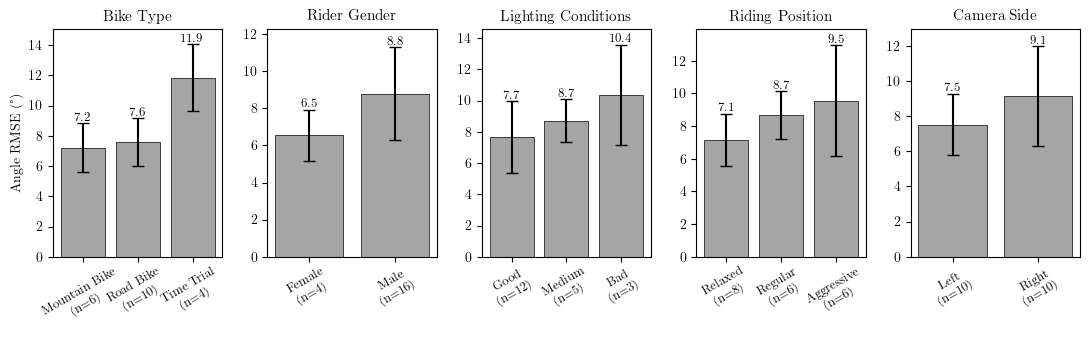

In [79]:
KEYPOINTS_NO_FOOT  = ['shoulder', 'elbow', 'wrist', 'hip', 'knee', 'ankle']
JOINTS_NO_ANKLE    = ['knee', 'hip', 'elbow']

VIDEO_METADATA = [
    {'gender': 'male',   'side': 'right', 'bike_type': 'time trial',   'position': 'aggressive', 'lighting': 'good'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'time trial',   'position': 'aggressive', 'lighting': 'bad'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'time trial',   'position': 'aggressive', 'lighting': 'medium'},
    {'gender': 'female', 'side': 'right', 'bike_type': 'mountain bike','position': 'relaxed',    'lighting': 'good'},
    {'gender': 'female', 'side': 'left',  'bike_type': 'road bike',    'position': 'relaxed',    'lighting': 'good'},
    {'gender': 'female', 'side': 'left',  'bike_type': 'road bike',    'position': 'aggressive', 'lighting': 'good'},
    {'gender': 'female', 'side': 'left',  'bike_type': 'road bike',    'position': 'regular',    'lighting': 'good'},
    {'gender': 'male',   'side': 'left',  'bike_type': 'mountain bike','position': 'aggressive', 'lighting': 'good'},
    {'gender': 'male',   'side': 'left',  'bike_type': 'mountain bike','position': 'relaxed',    'lighting': 'medium'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'mountain bike','position': 'relaxed',    'lighting': 'medium'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'mountain bike','position': 'relaxed',    'lighting': 'good'},
    {'gender': 'male',   'side': 'left',  'bike_type': 'mountain bike','position': 'relaxed',    'lighting': 'good'},
    {'gender': 'male',   'side': 'left',  'bike_type': 'road bike',    'position': 'regular',    'lighting': 'good'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'road bike',    'position': 'regular',    'lighting': 'good'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'road bike',    'position': 'regular',    'lighting': 'bad'},
    {'gender': 'male',   'side': 'left',  'bike_type': 'road bike',    'position': 'regular',    'lighting': 'medium'},
    {'gender': 'male',   'side': 'left',  'bike_type': 'road bike',    'position': 'relaxed',    'lighting': 'good'},
    {'gender': 'male',   'side': 'left',  'bike_type': 'road bike',    'position': 'aggressive', 'lighting': 'medium'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'road bike',    'position': 'relaxed',    'lighting': 'bad'},
    {'gender': 'male',   'side': 'right', 'bike_type': 'time trial',   'position': 'regular',    'lighting': 'good'},
]

CATEGORY_LABELS = {
    'lighting':  'Lighting Conditions',
    'bike_type': 'Bike Type',
    'position':  'Riding Position',
    'side':      'Camera Side',
    'gender':    'Rider Gender',
}


def _extract_per_video_scores(results, model_name, video_id):
    """
    Extract RMSE (no ankle) for a single video from the per_video structure.

    Returns rmse or None if the video produced no metrics.
    """
    vm = results[model_name]['per_video'].get(str(video_id))
    if vm is None:
        vm = results[model_name]['per_video'].get(video_id)
    if not vm:
        return None

    rmse_dict = vm.get('angle_rmse', {})
    rmse_vals = [rmse_dict[j] for j in JOINTS_NO_ANKLE if j in rmse_dict]
    return float(np.mean(rmse_vals)) if rmse_vals else None


def plot_metadata_analysis(results, video_metadata, model_names,
                           figsize=(11, 4), pdf_output_path=None):
    """
    Single-row subplot grid: RMSE (no ankle) per metadata category.
    Bars are averaged across model_names and videos in each category bucket.
    """
    exclude_keys = {'location'}
    all_keys = sorted(
        k for k in video_metadata[0].keys() if k not in exclude_keys
    )

    categories = {
        k: sorted(set(v[k] for v in video_metadata))
        for k in all_keys
    }

    n_cats = len(categories)
    fig, axes = plt.subplots(1, n_cats, figsize=figsize)

    print("Metadata analysis - RMSE (no ankle)")

    for col_idx, (category, values) in enumerate(categories.items()):
        ax = axes[col_idx]

        rmse_data = {v: [] for v in values}

        for model_name in model_names:
            for video_idx, meta in enumerate(video_metadata):
                cat_val = meta[category]
                scores = [
                    _extract_per_video_scores(results, m, video_idx)
                    for m in model_names
                ]
                scores = [s for s in scores if s is not None]
                if scores:
                    rmse_data[cat_val].append(np.mean(scores))

        sorted_values = sorted(
            values,
            key=lambda v: np.mean(rmse_data[v]) if rmse_data[v] else 0,
        )

        print(f"\n  {category}:")

        rmse_means, rmse_stds, counts = [], [], []
        for val in sorted_values:
            n   = len(rmse_data[val]) // max(len(model_names), 1)
            rm  = np.mean(rmse_data[val]) if rmse_data[val] else 0.0
            rs  = np.std(rmse_data[val])  if rmse_data[val] else 0.0
            rmse_means.append(rm)
            rmse_stds.append(rs)
            counts.append(n)
            print(f"    {val:15s}  RMSE={rm:.2f}±{rs:.2f}°  (n={n})")

        x = np.arange(len(sorted_values))
        tick_labels = [
            f"{v.replace('_', ' ').title()}\n(n={n})"
            for v, n in zip(sorted_values, counts)
        ]

        ax.bar(x, rmse_means, yerr=rmse_stds, capsize=4,
               color=plt.cm.Greys(0.45), edgecolor='black', linewidth=0.5)
        for i, (m, s) in enumerate(zip(rmse_means, rmse_stds)):
            ax.text(i, m + s + 0.15, f'{m:.1f}', ha='center', fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=30, ha='center', fontsize=9)
        ax.set_ylim(0, max(m + s for m, s in zip(rmse_means, rmse_stds)) + 1)
        ax.set_title(CATEGORY_LABELS.get(category, category.replace('_', ' ').title()),
                     fontsize=11)

    axes[0].set_ylabel('Angle RMSE (°)', fontsize=10)

    plt.tight_layout()

    if pdf_output_path:
        fig.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
        print(f"\nSaved → {pdf_output_path}")

    plt.show()
    return fig


fig_meta = plot_metadata_analysis(
    results,
    VIDEO_METADATA,
    model_names=list(best_models.values()),
    figsize=(11, 3.5),
    pdf_output_path='./plots/metadata.pdf',
)

Cramér's V association matrix:
           Bike Type  Gender  Lighting  Position   Side
Bike Type      1.000   0.289     0.207     0.530  0.529
Gender         0.289   1.000     0.408     0.102  0.125
Lighting       0.207   0.408     1.000     0.116  0.420
Position       0.530   0.102     0.116     1.000  0.000
Side           0.529   0.125     0.420     0.000  1.000
Saved → ./plots/metadata_covariance.pdf


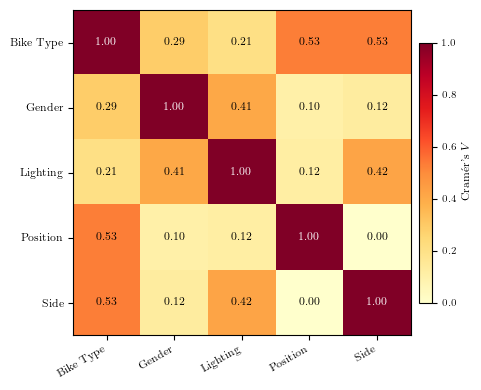

In [80]:
CATEGORY_LABELS = {
    'lighting':  'Lighting',
    'bike_type': 'Bike Type',
    'position':  'Position',
    'side':      'Side',
    'gender':    'Gender',
}

def plot_metadata_covariance(video_metadata, figsize=(5, 4), pdf_output_path=None):
    exclude_keys = {'location'}
    categories = sorted(k for k in video_metadata[0].keys() if k not in exclude_keys)
    n_cats = len(categories)

    # --- Cramér's V matrix ---
    matrix = np.zeros((n_cats, n_cats))
    for i, cat1 in enumerate(categories):
        for j, cat2 in enumerate(categories):
            if i == j:
                matrix[i, j] = 1.0
            elif i > j:
                matrix[i, j] = matrix[j, i]
            else:
                vals1 = [v[cat1] for v in video_metadata]
                vals2 = [v[cat2] for v in video_metadata]
                u1, u2 = sorted(set(vals1)), sorted(set(vals2))
                contingency = np.zeros((len(u1), len(u2)))
                for a, b in zip(vals1, vals2):
                    contingency[u1.index(a), u2.index(b)] += 1
                chi2, _, _, _ = chi2_contingency(contingency)
                min_dim = min(len(u1), len(u2)) - 1
                matrix[i, j] = np.sqrt(chi2 / (len(video_metadata) * min_dim)) if min_dim > 0 else 0.0

    display_labels = [CATEGORY_LABELS.get(c, c.replace('_', ' ').title()) for c in categories]

    print("Cramér's V association matrix:")
    df = pd.DataFrame(matrix.round(3), index=display_labels, columns=display_labels)
    print(df)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(r"Cram\'{e}r's $V$", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.set_xticks(range(n_cats))
    ax.set_yticks(range(n_cats))
    ax.set_xticklabels(display_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(display_labels, fontsize=8)

    for i in range(n_cats):
        for j in range(n_cats):
            val = matrix[i, j]
            # flip text colour so it's readable on dark cells
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color)

    plt.tight_layout()

    if pdf_output_path:
        fig.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
        print(f"Saved → {pdf_output_path}")

    plt.show()

plot_metadata_covariance(VIDEO_METADATA, pdf_output_path='./plots/metadata_covariance.pdf')

Robustness analysis — ΔRMSE (worst − best level, no ankle)

  Bike Type  (levels: ['mountain bike', 'road bike', 'time trial'])
    YOLO11           Δ=1.71°  (best: mountain bike=11.13°, worst: time trial=12.83°)
    MediaPipe        Δ=17.55°  (best: mountain bike=7.67°, worst: time trial=25.22°)
    OpenPose         Δ=1.08°  (best: mountain bike=5.15°, worst: time trial=6.23°)
    HRNet            Δ=1.94°  (best: mountain bike=7.09°, worst: time trial=9.04°)
    ViTPose          Δ=0.86°  (best: mountain bike=5.10°, worst: time trial=5.96°)

  Gender  (levels: ['female', 'male'])
    YOLO11           Δ=1.04°  (best: male=11.31°, worst: female=12.35°)
    MediaPipe        Δ=7.06°  (best: female=5.60°, worst: male=12.66°)
    OpenPose         Δ=2.03°  (best: female=4.02°, worst: male=6.06°)
    HRNet            Δ=1.27°  (best: female=6.81°, worst: male=8.07°)
    ViTPose          Δ=1.86°  (best: female=3.90°, worst: male=5.76°)

  Lighting  (levels: ['bad', 'good', 'medium'])
    YOLO11 

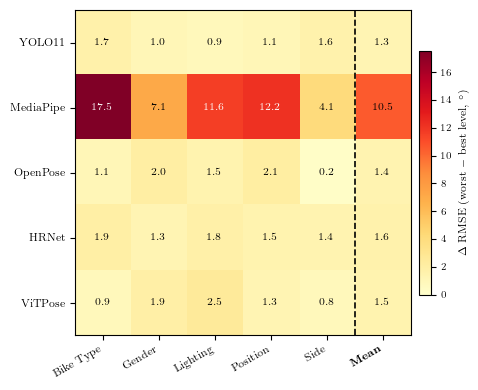

In [81]:
def plot_robustness_heatmap(results, video_metadata, best_models,
                             figsize=(5, 4), pdf_output_path=None):
    """
    Heatmap of RMSE sensitivity per model per metadata category.

    Each cell = RMSE(worst level) - RMSE(best level) for that model/category pair.
    A small delta means the model is robust to that variable;
    a large delta means performance degrades significantly across levels.
    """
    exclude_keys = {'location'}
    categories   = sorted(k for k in video_metadata[0].keys() if k not in exclude_keys)
    family_names = list(best_models.keys())

    n_rows = len(family_names)
    n_cols = len(categories)

    delta_matrix  = np.full((n_rows, n_cols), np.nan)
    annot_strings = [[''] * n_cols for _ in range(n_rows)]

    print("Robustness analysis — ΔRMSE (worst − best level, no ankle)")

    for col_idx, category in enumerate(categories):
        levels = sorted(set(m[category] for m in video_metadata))
        print(f"\n  {CATEGORY_LABELS.get(category, category)}  (levels: {levels})")

        for row_idx, (family_name, model_name) in enumerate(best_models.items()):
            level_means = {}
            for level in levels:
                video_indices = [i for i, m in enumerate(video_metadata)
                                 if m[category] == level]
                scores = [_extract_per_video_scores(results, model_name, i)
                          for i in video_indices]
                scores = [s for s in scores if s is not None]
                if scores:
                    level_means[level] = np.mean(scores)

            if len(level_means) >= 2:
                best_val  = min(level_means.values())
                worst_val = max(level_means.values())
                delta = worst_val - best_val
                delta_matrix[row_idx, col_idx] = delta

                best_level  = min(level_means, key=level_means.get)
                worst_level = max(level_means, key=level_means.get)
                print(f"    {family_name:15s}  Δ={delta:.2f}°  "
                      f"(best: {best_level}={best_val:.2f}°, "
                      f"worst: {worst_level}={worst_val:.2f}°)")
                annot_strings[row_idx][col_idx] = f'{delta:.1f}'
            else:
                annot_strings[row_idx][col_idx] = '—'

    # Append mean-delta column (overall sensitivity score per model)
    mean_deltas = np.nanmean(delta_matrix, axis=1, keepdims=True)
    plot_matrix = np.hstack([delta_matrix, mean_deltas])

    col_labels = [CATEGORY_LABELS.get(c, c.replace('_', ' ').title())
                  for c in categories] + [r'\textbf{Mean}']

    mean_annot  = [[f'{v:.1f}' if not np.isnan(v) else '—'] for v in mean_deltas.flatten()]
    annot_full  = [row + [m[0]] for row, m in zip(annot_strings, mean_annot)]

    print("\n  Overall sensitivity (mean Δ across categories):")
    for family_name, delta in zip(family_names, mean_deltas.flatten()):
        print(f"    {family_name:15s}  {delta:.2f}°")

    # Plot 
    vmax = np.nanmax(plot_matrix[:, :-1])   # normalise colour to category columns only

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(plot_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)

    cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label(r'$\Delta$ RMSE (worst $-$ best level, $^\circ$)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.set_xticks(range(len(col_labels)))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(family_names, fontsize=8)

    # Separate mean column with a vertical line
    ax.axvline(x=n_cols - 0.5, color='black', linewidth=1.2, linestyle='--')

    # Cell annotations
    for i in range(n_rows):
        for j in range(len(col_labels)):
            val = plot_matrix[i, j]
            text = annot_full[i][j]
            text_color = 'white' if (not np.isnan(val) and val > vmax * 0.65) else 'black'
            weight = 'bold' if j == n_cols else 'normal'   # bold mean column
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=7.5, color=text_color, fontweight=weight)

    plt.tight_layout()

    if pdf_output_path:
        fig.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
        print(f"\nSaved → {pdf_output_path}")

    plt.show()


plot_robustness_heatmap(
    results, VIDEO_METADATA, best_models,
    figsize=(5, 4),
    pdf_output_path='./plots/robustness_heatmap.pdf',
)

Saved → ./plots/metadata_per_model.pdf


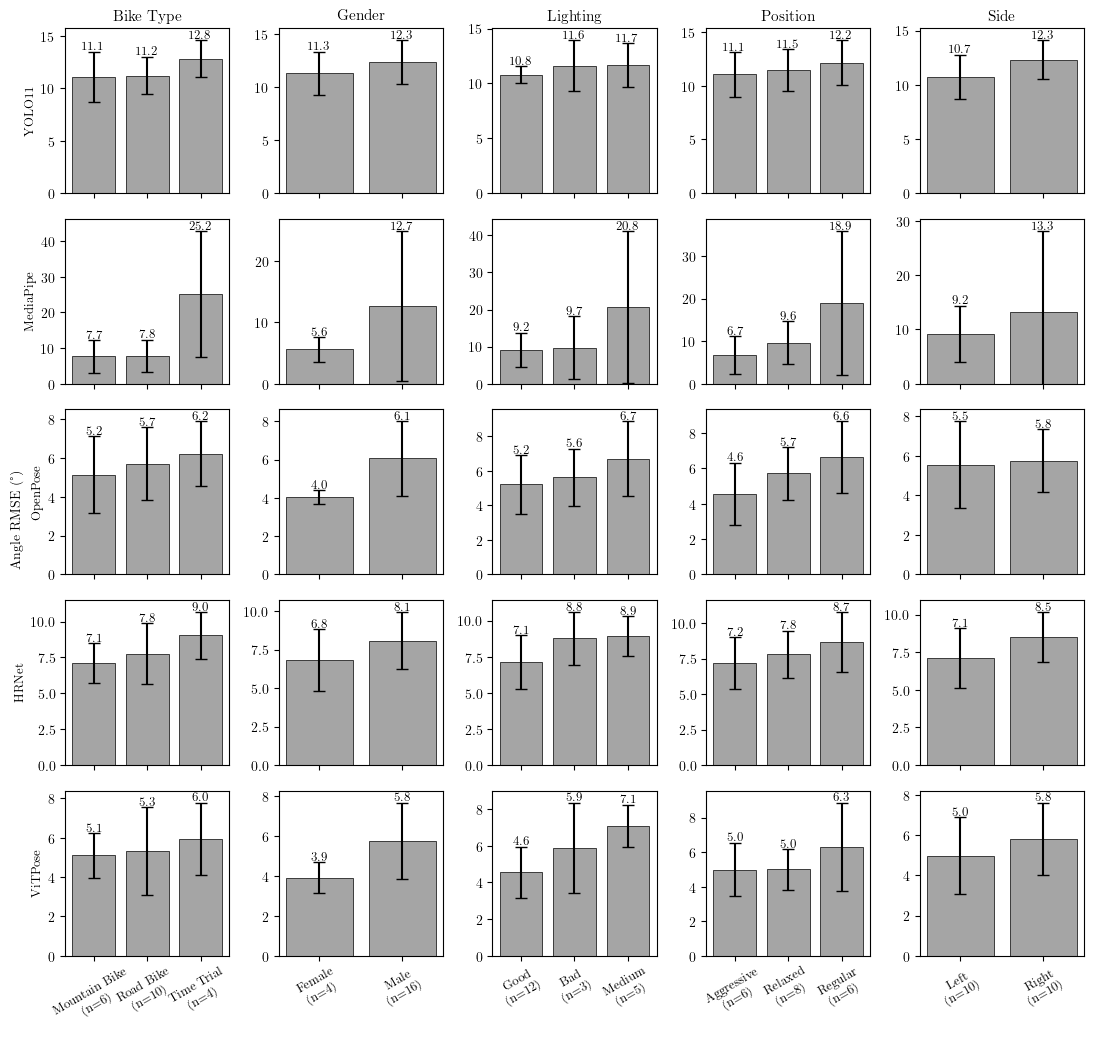

In [84]:
def plot_metadata_analysis_per_model(results, video_metadata, best_models,
                                      figsize=(11, 4), pdf_output_path=None):
    exclude_keys = {'location'}
    all_keys = sorted(k for k in video_metadata[0].keys() if k not in exclude_keys)
    categories = {k: sorted(set(v[k] for v in video_metadata)) for k in all_keys}
    n_cats = len(categories)
    n_models = len(best_models)

    fig, axes = plt.subplots(n_models, n_cats, figsize=figsize)

    for row_idx, (family_name, model_name) in enumerate(best_models.items()):
        for col_idx, (category, values) in enumerate(categories.items()):
            ax = axes[row_idx, col_idx]

            rmse_data = {v: [] for v in values}
            for video_idx, meta in enumerate(video_metadata):
                cat_val = meta[category]
                score = _extract_per_video_scores(results, model_name, video_idx)
                if score is not None:
                    rmse_data[cat_val].append(score)

            sorted_values = sorted(
                values,
                key=lambda v: np.mean(rmse_data[v]) if rmse_data[v] else 0,
            )

            rmse_means, rmse_stds, counts = [], [], []
            for val in sorted_values:
                n  = len(rmse_data[val])
                rm = np.mean(rmse_data[val]) if rmse_data[val] else 0.0
                rs = np.std(rmse_data[val])  if rmse_data[val] else 0.0
                rmse_means.append(rm)
                rmse_stds.append(rs)
                counts.append(n)

            x = np.arange(len(sorted_values))

            ax.bar(x, rmse_means, yerr=rmse_stds, capsize=4,
                   color=plt.cm.Greys(0.45), edgecolor='black', linewidth=0.5)
            ax_range = max(m + s for m, s in zip(rmse_means, rmse_stds))
            for i, (m, s) in enumerate(zip(rmse_means, rmse_stds)):
                ax.text(i, m + s + (ax_range * 0.015), f'{m:.1f}', ha='center', fontsize=9)
            ax.set_xticks(x)

            if row_idx == n_models - 1:
                tick_labels = [
                    f"{v.replace('_', ' ').title()}\n(n={n})"
                    for v, n in zip(sorted_values, counts)
                ]
                ax.set_xticklabels(tick_labels, rotation=30, ha='center', fontsize=9)
            else:
                ax.set_xticklabels([])

            if row_idx == 0:
                ax.set_title(CATEGORY_LABELS.get(category, category.replace('_', ' ').title()),
                             fontsize=11)

            top = max(m + s for m, s in zip(rmse_means, rmse_stds))
            ax.set_ylim(0, top + (top * 0.08))

        axes[row_idx, 0].set_ylabel(family_name, fontsize=9)

    fig.text(0.01, 0.5, 'Angle RMSE (°)', va='center', rotation='vertical', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(left=0.06)

    if pdf_output_path:
        fig.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
        print(f"Saved → {pdf_output_path}")

    plt.show()


plot_metadata_analysis_per_model(
    results,
    VIDEO_METADATA,
    best_models,
    figsize=(11, 2.1 * len(best_models)),
    pdf_output_path='./plots/metadata_per_model.pdf',
)